<a href="https://colab.research.google.com/github/AhalaAyyalas/MachineLearning/blob/main/ML_Assign14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#@title Necessary Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load the digits dataset
digits = load_digits()
X = digits.data
y = digits.target

print(f"Original data shape: {X.shape}")
print(f"Target data shape: {y.shape}")

Original data shape: (1797, 64)
Target data shape: (1797,)


In [12]:
#@title Splitting and Scaling data

# Splitting the original data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")

Scaled training data shape: (1437, 64)
Scaled testing data shape: (360, 64)


Number of components selected by PCA: 40
PCA transformed training data shape: (1437, 40)
PCA transformed testing data shape: (360, 40)


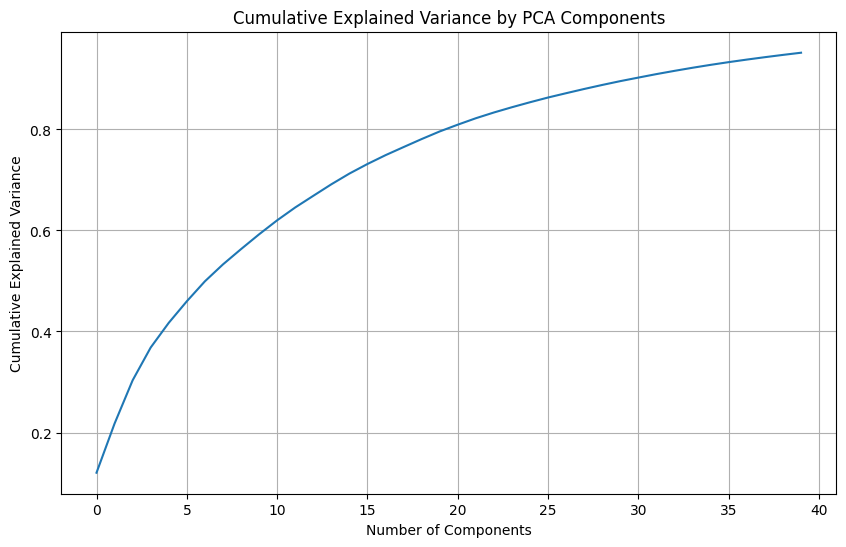

In [13]:
#@title Applying PCA

# Choosing n_components to explain 95% of the variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Number of components selected by PCA: {pca.n_components_}")
print(f"PCA transformed training data shape: {X_train_pca.shape}")
print(f"PCA transformed testing data shape: {X_test_pca.shape}")

# Visualizing explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

In [14]:
#@title Training a Classifier on the original scaled data

# Training a classifier on the original scaled data
clf_original = LogisticRegression(max_iter=1000, random_state=42)
clf_original.fit(X_train_scaled, y_train)
y_pred_original = clf_original.predict(X_test_scaled)
accuracy_original = accuracy_score(y_test, y_pred_original)

print(f"Accuracy on original scaled data: {accuracy_original:.4f}")

Accuracy on original scaled data: 0.9722


Now, let's train a Logistic Regression classifier on the **PCA-transformed data** and evaluate its accuracy.

In [15]:
#@title Training a classifier on PCA

# Training a classifier on the PCA-transformed data
clf_pca = LogisticRegression(max_iter=1000, random_state=42)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"Accuracy on PCA-transformed data: {accuracy_pca:.4f}")

Accuracy on PCA-transformed data: 0.9611


## Observations

Based on the results, we can make the following observations:

*   **Dimensionality Reduction**: PCA successfully reduced the number of features from `64` to `40` while retaining `95%` of the variance. This significantly reduces the complexity of the data.

*   **Accuracy Comparison**:
    *   Accuracy on original scaled data: `0.9722`
    *   Accuracy on PCA-transformed data: `0.9611`

    We observe that the accuracy using PCA-transformed data is `slightly lower`. This demonstrates that PCA can be very effective in reducing dimensionality without a significant loss in classification performance, and sometimes even improving it due to noise reduction.

*   **Computational Efficiency**: Training a model on a dataset with fewer features (after PCA) generally leads to faster training times and reduced memory usage. This is particularly beneficial for very high-dimensional datasets.

*   **Overfitting Reduction**: By removing redundant or noisy features, PCA can sometimes help in reducing overfitting, leading to better generalization on unseen data.

**Conclusion**: PCA is a powerful technique for dimensionality reduction, offering benefits in terms of computational efficiency and potentially improved model performance, especially when dealing with highly correlated features or noise in the original data. In this specific case with the `load_digits` dataset, we see that a significant reduction in features can be achieved while maintaining comparable classification accuracy.